In [1]:
!git clone https://github.com/eliftufekci/k_shortest_path_with_diversity.git

Cloning into 'k_shortest_path_with_diversity'...
remote: Enumerating objects: 496, done.
remote: Counting objects: 100% (22/22), done.
remote: Compressing objects: 100% (22/22), done.
remote: Total 496 (delta 5), reused 0 (delta 0), pack-reused 474 (from 1)
Receiving objects: 100% (496/496), 751.06 KiB | 9.88 MiB/s, done.
Resolving deltas: 100% (317/317), done.


In [2]:
import sys

top_level_container_dir = "k_shortest_path_with_diversity/"

if top_level_container_dir not in sys.path:
    sys.path.insert(0, top_level_container_dir)

In [3]:
import gc
import networkx as nx
import random
import datetime
import numpy as np

from k_shortest_path_with_diversity.examples import draw_line_chart, download_and_prepare_graphs
from k_shortest_path_with_diversity.examples.draw_distribution import draw_time_distribution, draw_num_of_path_distribution
from k_shortest_path_with_diversity.src.algorithms import FindKSPD, FindKSPD_Minus

In [4]:
def run_algorithm(algorithm, G, threshold, k, node_pairs):
    times = []
    num_paths = []

    for src, dest in node_pairs:
        print(f"\nComparing algorithms for SRC: {src}, DEST: {dest}")

        start_time = datetime.datetime.now()
        alg = algorithm(G, threshold)
        result = alg.find_paths(src=src, dest=dest, k=k)
        end_time = datetime.datetime.now()
        execution_time = end_time - start_time

        times.append(execution_time.total_seconds())
        num_paths.append(alg.number_of_paths_explored)

    return times, num_paths

In [5]:
def upload_graph(filepath, num_pairs):
    G = nx.DiGraph()
    with open(filepath) as f:
        for line in f:
            parts = line.split()
            if len(parts) == 3:  # Weighted graph (3 parçalı satır: kaynak, hedef, ağırlık)
                u, v, weight = int(parts[0]), int(parts[1]), float(parts[2])
                G.add_edge(u, v, weight=weight)
            elif len(parts) == 2:  # Unweighted graph (2 parçalı satır: kaynak ve hedef)
                u, v = map(int, parts)
                G.add_edge(u, v, weight=1)  # Ağırlıksız kenarları varsayılan olarak '1' ağırlıkla ekle
            else:
                raise ValueError("Unexpected line format in graph file.")

    node_pairs = []
    for _ in range(num_pairs):
        src = random.choice(list(G.nodes()))
        reachable = list(nx.descendants(G, src))

        while not reachable:
            src = random.choice(list(G.nodes()))
            reachable = list(nx.descendants(G, src))

        dest = random.choice(reachable)
        node_pairs.append((src, dest))

    return G, node_pairs

In [6]:
download_and_prepare_graphs()

k_list = [5, 10, 15, 20]
diversity_threshold = 0.6

Downloading: https://snap.stanford.edu/data/web-Google.txt.gz
Extracting: /content/graph-data/web-Google.txt.gz -> /content/graph-data/web-Google.txt
Removed archive: /content/graph-data/web-Google.txt.gz
Done: /content/graph-data/web-Google.txt
Downloading: https://snap.stanford.edu/data/wiki-Talk.txt.gz
Extracting: /content/graph-data/wiki-Talk.txt.gz -> /content/graph-data/wiki-Talk.txt
Removed archive: /content/graph-data/wiki-Talk.txt.gz
Done: /content/graph-data/wiki-Talk.txt
Downloading: https://www.diag.uniroma1.it/challenge9/data/USA-road-d/USA-road-d.FLA.gr.gz
Extracting: /content/graph-data/USA-road-d.FLA.gr.gz -> /content/graph-data/USA-road-d.FLA.gr
Removed archive: /content/graph-data/USA-road-d.FLA.gr.gz
Done: /content/graph-data/USA-road-d.FLA.gr
Downloading: https://www.diag.uniroma1.it/challenge9/data/USA-road-d/USA-road-d.COL.gr.gz
Extracting: /content/graph-data/USA-road-d.COL.gr.gz -> /content/graph-data/USA-road-d.COL.gr
Removed archive: /content/graph-data/USA-ro

In [ ]:
web_google_path = "/content/graph-data/web-Google.txt"
num_pairs = 20
G, node_pairs = upload_graph(web_google_path, num_pairs)


In [8]:
node_pairs = [(187080, 356676), (74834, 454020), (152301, 223267), (293372, 219157), (797232, 146928), (337883, 301360), (7689, 658381), (262237, 679943), (289027, 323855), (564822, 275121), (26248, 878103), (53860, 282820), (662685, 53075), (193465, 185445), (353591, 846755), (242448, 724791), (503088, 204151), (759204, 893870), (809744, 814560), (624868, 780863)]

In [ ]:
all_results = []

for k_to_find in k_list:
    print("working with KSPD")
    kspd_times, kspd_num_paths = run_algorithm(FindKSPD, G, diversity_threshold, k_to_find, node_pairs)

    print(f"kspd_times: {kspd_times}")
    print(f"kspd_num_paths: {kspd_num_paths}")

    print("working with KSPD_Minus")
    kspd_minus_times, kspd_minus_num_paths = run_algorithm(FindKSPD_Minus, G, diversity_threshold, k_to_find, node_pairs)

    print(f"kspd_minus_times: {kspd_minus_times}")
    print(f"kspd_minus_num_paths: {kspd_minus_num_paths}")

    web_google_result = (
            (np.average(kspd_times) if kspd_times else 0,
            np.average(kspd_num_paths) if kspd_num_paths else 0,
            kspd_times, kspd_num_paths),
            (np.average(kspd_minus_times) if kspd_minus_times else 0,
            np.average(kspd_minus_num_paths) if kspd_minus_num_paths else 0,
            kspd_minus_times, kspd_minus_num_paths)
        )
    print(web_google_result)

    all_results.append(web_google_result)

In [ ]:
all_results = []

print("working with KSPD")
kspd_times, kspd_num_paths = run_algorithm(FindKSPD, G, diversity_threshold, 5, node_pairs)

print(f"kspd_times: {kspd_times}")
print(f"kspd_num_paths: {kspd_num_paths}")

working with KSPD

Comparing algorithms for SRC: 187080, DEST: 356676

Comparing algorithms for SRC: 74834, DEST: 454020

Comparing algorithms for SRC: 152301, DEST: 223267

Comparing algorithms for SRC: 293372, DEST: 219157

Comparing algorithms for SRC: 797232, DEST: 146928

Comparing algorithms for SRC: 337883, DEST: 301360

Comparing algorithms for SRC: 7689, DEST: 658381

Comparing algorithms for SRC: 262237, DEST: 679943

Comparing algorithms for SRC: 289027, DEST: 323855

Comparing algorithms for SRC: 564822, DEST: 275121

Comparing algorithms for SRC: 26248, DEST: 878103

Comparing algorithms for SRC: 53860, DEST: 282820

Comparing algorithms for SRC: 662685, DEST: 53075

Comparing algorithms for SRC: 193465, DEST: 185445

Comparing algorithms for SRC: 353591, DEST: 846755

Comparing algorithms for SRC: 242448, DEST: 724791

Comparing algorithms for SRC: 503088, DEST: 204151

Comparing algorithms for SRC: 759204, DEST: 893870

Comparing algorithms for SRC: 809744, DEST: 814560


In [9]:
print("working with KSPD_Minus")
kspd_minus_times, kspd_minus_num_paths = run_algorithm(FindKSPD_Minus, G, diversity_threshold, 5, node_pairs)

print(f"kspd_minus_times: {kspd_minus_times}")
print(f"kspd_minus_num_paths: {kspd_minus_num_paths}")

web_google_result = (
        (np.average(kspd_times) if kspd_times else 0,
        np.average(kspd_num_paths) if kspd_num_paths else 0,
        kspd_times, kspd_num_paths),
        (np.average(kspd_minus_times) if kspd_minus_times else 0,
        np.average(kspd_minus_num_paths) if kspd_minus_num_paths else 0,
        kspd_minus_times, kspd_minus_num_paths)
    )
print(web_google_result)

all_results.append(web_google_result)

working with KSPD_Minus

Comparing algorithms for SRC: 187080, DEST: 356676

Comparing algorithms for SRC: 74834, DEST: 454020

Comparing algorithms for SRC: 152301, DEST: 223267

Comparing algorithms for SRC: 293372, DEST: 219157

Comparing algorithms for SRC: 797232, DEST: 146928

Comparing algorithms for SRC: 337883, DEST: 301360

Comparing algorithms for SRC: 7689, DEST: 658381

Comparing algorithms for SRC: 262237, DEST: 679943

Comparing algorithms for SRC: 289027, DEST: 323855

Comparing algorithms for SRC: 564822, DEST: 275121

Comparing algorithms for SRC: 26248, DEST: 878103

Comparing algorithms for SRC: 53860, DEST: 282820

Comparing algorithms for SRC: 662685, DEST: 53075

Comparing algorithms for SRC: 193465, DEST: 185445

Comparing algorithms for SRC: 353591, DEST: 846755

Comparing algorithms for SRC: 242448, DEST: 724791

Comparing algorithms for SRC: 503088, DEST: 204151

Comparing algorithms for SRC: 759204, DEST: 893870

Comparing algorithms for SRC: 809744, DEST: 8

NameError: name 'kspd_times' is not defined

In [10]:
all_results = []
kspd_times = [53.35007, 47.398449, 32.479196, 49.713751, 51.694397, 17.564216, 60.886247, 66.799033, 53.76848, 55.087908, 60.427925, 62.136247, 61.804074, 45.469422, 39.700853, 48.574582, 51.368457, 51.768499, 26.929617, 64.071801]
kspd_num_paths = [40, 8, 9, 26, 12, 4, 12, 14, 4, 28, 60, 122, 31, 31, 4, 7, 75, 39, 4, 8]

kspd_minus_times = [54.608745, 46.428424, 35.196179, 45.860836, 49.471065, 19.127654, 65.770962, 61.155102, 51.216532, 53.141298, 58.0928, 59.753101, 62.234602, 41.879315, 36.987285, 48.707418, 50.315162, 47.722614, 22.883117, 55.482083]
kspd_minus_num_paths = [40, 8, 26, 26, 12, 4, 12, 15, 4, 28, 60, 122, 31, 31, 4, 7, 75, 39, 4, 10]

web_google_result = (
        (np.average(kspd_times) if kspd_times else 0,
        np.average(kspd_num_paths) if kspd_num_paths else 0,
        kspd_times, kspd_num_paths),
        (np.average(kspd_minus_times) if kspd_minus_times else 0,
        np.average(kspd_minus_num_paths) if kspd_minus_num_paths else 0,
        kspd_minus_times, kspd_minus_num_paths)
    )
print(web_google_result)

all_results.append(web_google_result)

((np.float64(50.0496612), np.float64(26.9), [53.35007, 47.398449, 32.479196, 49.713751, 51.694397, 17.564216, 60.886247, 66.799033, 53.76848, 55.087908, 60.427925, 62.136247, 61.804074, 45.469422, 39.700853, 48.574582, 51.368457, 51.768499, 26.929617, 64.071801], [40, 8, 9, 26, 12, 4, 12, 14, 4, 28, 60, 122, 31, 31, 4, 7, 75, 39, 4, 8]), (np.float64(48.3017147), np.float64(27.9), [54.608745, 46.428424, 35.196179, 45.860836, 49.471065, 19.127654, 65.770962, 61.155102, 51.216532, 53.141298, 58.0928, 59.753101, 62.234602, 41.879315, 36.987285, 48.707418, 50.315162, 47.722614, 22.883117, 55.482083], [40, 8, 26, 26, 12, 4, 12, 15, 4, 28, 60, 122, 31, 31, 4, 7, 75, 39, 4, 10]))


In [11]:
print("working with KSPD")
kspd_times, kspd_num_paths = run_algorithm(FindKSPD, G, diversity_threshold, 10, node_pairs)

print(f"kspd_times: {kspd_times}")
print(f"kspd_num_paths: {kspd_num_paths}")

print("working with KSPD_Minus")
kspd_minus_times, kspd_minus_num_paths = run_algorithm(FindKSPD_Minus, G, diversity_threshold, 10, node_pairs)

print(f"kspd_minus_times: {kspd_minus_times}")
print(f"kspd_minus_num_paths: {kspd_minus_num_paths}")

web_google_result = (
        (np.average(kspd_times) if kspd_times else 0,
        np.average(kspd_num_paths) if kspd_num_paths else 0,
        kspd_times, kspd_num_paths),
        (np.average(kspd_minus_times) if kspd_minus_times else 0,
        np.average(kspd_minus_num_paths) if kspd_minus_num_paths else 0,
        kspd_minus_times, kspd_minus_num_paths)
    )
print(web_google_result)

all_results.append(web_google_result)

working with KSPD

Comparing algorithms for SRC: 187080, DEST: 356676

Comparing algorithms for SRC: 74834, DEST: 454020

Comparing algorithms for SRC: 152301, DEST: 223267

Comparing algorithms for SRC: 293372, DEST: 219157

Comparing algorithms for SRC: 797232, DEST: 146928

Comparing algorithms for SRC: 337883, DEST: 301360

Comparing algorithms for SRC: 7689, DEST: 658381

Comparing algorithms for SRC: 262237, DEST: 679943

Comparing algorithms for SRC: 289027, DEST: 323855

Comparing algorithms for SRC: 564822, DEST: 275121

Comparing algorithms for SRC: 26248, DEST: 878103

Comparing algorithms for SRC: 53860, DEST: 282820

Comparing algorithms for SRC: 662685, DEST: 53075

Comparing algorithms for SRC: 193465, DEST: 185445

Comparing algorithms for SRC: 353591, DEST: 846755

Comparing algorithms for SRC: 242448, DEST: 724791

Comparing algorithms for SRC: 503088, DEST: 204151

Comparing algorithms for SRC: 759204, DEST: 893870

Comparing algorithms for SRC: 809744, DEST: 814560


In [12]:
print("working with KSPD")
kspd_times, kspd_num_paths = run_algorithm(FindKSPD, G, diversity_threshold, 15, node_pairs)

print(f"kspd_times: {kspd_times}")
print(f"kspd_num_paths: {kspd_num_paths}")

working with KSPD

Comparing algorithms for SRC: 187080, DEST: 356676

Comparing algorithms for SRC: 74834, DEST: 454020

Comparing algorithms for SRC: 152301, DEST: 223267

Comparing algorithms for SRC: 293372, DEST: 219157

Comparing algorithms for SRC: 797232, DEST: 146928

Comparing algorithms for SRC: 337883, DEST: 301360

Comparing algorithms for SRC: 7689, DEST: 658381

Comparing algorithms for SRC: 262237, DEST: 679943

Comparing algorithms for SRC: 289027, DEST: 323855

Comparing algorithms for SRC: 564822, DEST: 275121

Comparing algorithms for SRC: 26248, DEST: 878103

Comparing algorithms for SRC: 53860, DEST: 282820

Comparing algorithms for SRC: 662685, DEST: 53075

Comparing algorithms for SRC: 193465, DEST: 185445

Comparing algorithms for SRC: 353591, DEST: 846755

Comparing algorithms for SRC: 242448, DEST: 724791

Comparing algorithms for SRC: 503088, DEST: 204151

Comparing algorithms for SRC: 759204, DEST: 893870

Comparing algorithms for SRC: 809744, DEST: 814560


In [13]:
print("working with KSPD_Minus")
kspd_minus_times, kspd_minus_num_paths = run_algorithm(FindKSPD_Minus, G, diversity_threshold, 15, node_pairs)

print(f"kspd_minus_times: {kspd_minus_times}")
print(f"kspd_minus_num_paths: {kspd_minus_num_paths}")

web_google_result = (
        (np.average(kspd_times) if kspd_times else 0,
        np.average(kspd_num_paths) if kspd_num_paths else 0,
        kspd_times, kspd_num_paths),
        (np.average(kspd_minus_times) if kspd_minus_times else 0,
        np.average(kspd_minus_num_paths) if kspd_minus_num_paths else 0,
        kspd_minus_times, kspd_minus_num_paths)
    )
print(web_google_result)

all_results.append(web_google_result)

working with KSPD_Minus

Comparing algorithms for SRC: 187080, DEST: 356676

Comparing algorithms for SRC: 74834, DEST: 454020

Comparing algorithms for SRC: 152301, DEST: 223267

Comparing algorithms for SRC: 293372, DEST: 219157

Comparing algorithms for SRC: 797232, DEST: 146928

Comparing algorithms for SRC: 337883, DEST: 301360

Comparing algorithms for SRC: 7689, DEST: 658381

Comparing algorithms for SRC: 262237, DEST: 679943

Comparing algorithms for SRC: 289027, DEST: 323855

Comparing algorithms for SRC: 564822, DEST: 275121

Comparing algorithms for SRC: 26248, DEST: 878103

Comparing algorithms for SRC: 53860, DEST: 282820

Comparing algorithms for SRC: 662685, DEST: 53075

Comparing algorithms for SRC: 193465, DEST: 185445

Comparing algorithms for SRC: 353591, DEST: 846755

Comparing algorithms for SRC: 242448, DEST: 724791

Comparing algorithms for SRC: 503088, DEST: 204151

Comparing algorithms for SRC: 759204, DEST: 893870

Comparing algorithms for SRC: 809744, DEST: 8

In [14]:
print("working with KSPD")
kspd_times, kspd_num_paths = run_algorithm(FindKSPD, G, diversity_threshold, 20, node_pairs)

print(f"kspd_times: {kspd_times}")
print(f"kspd_num_paths: {kspd_num_paths}")

working with KSPD

Comparing algorithms for SRC: 187080, DEST: 356676

Comparing algorithms for SRC: 74834, DEST: 454020

Comparing algorithms for SRC: 152301, DEST: 223267

Comparing algorithms for SRC: 293372, DEST: 219157

Comparing algorithms for SRC: 797232, DEST: 146928

Comparing algorithms for SRC: 337883, DEST: 301360

Comparing algorithms for SRC: 7689, DEST: 658381

Comparing algorithms for SRC: 262237, DEST: 679943

Comparing algorithms for SRC: 289027, DEST: 323855

Comparing algorithms for SRC: 564822, DEST: 275121

Comparing algorithms for SRC: 26248, DEST: 878103

Comparing algorithms for SRC: 53860, DEST: 282820

Comparing algorithms for SRC: 662685, DEST: 53075

Comparing algorithms for SRC: 193465, DEST: 185445

Comparing algorithms for SRC: 353591, DEST: 846755

Comparing algorithms for SRC: 242448, DEST: 724791

Comparing algorithms for SRC: 503088, DEST: 204151

Comparing algorithms for SRC: 759204, DEST: 893870

Comparing algorithms for SRC: 809744, DEST: 814560


In [15]:
print("working with KSPD_Minus")
kspd_minus_times, kspd_minus_num_paths = run_algorithm(FindKSPD_Minus, G, diversity_threshold, 20, node_pairs)

print(f"kspd_minus_times: {kspd_minus_times}")
print(f"kspd_minus_num_paths: {kspd_minus_num_paths}")

web_google_result = (
        (np.average(kspd_times) if kspd_times else 0,
        np.average(kspd_num_paths) if kspd_num_paths else 0,
        kspd_times, kspd_num_paths),
        (np.average(kspd_minus_times) if kspd_minus_times else 0,
        np.average(kspd_minus_num_paths) if kspd_minus_num_paths else 0,
        kspd_minus_times, kspd_minus_num_paths)
    )
print(web_google_result)

all_results.append(web_google_result)

working with KSPD_Minus

Comparing algorithms for SRC: 187080, DEST: 356676

Comparing algorithms for SRC: 74834, DEST: 454020

Comparing algorithms for SRC: 152301, DEST: 223267

Comparing algorithms for SRC: 293372, DEST: 219157

Comparing algorithms for SRC: 797232, DEST: 146928

Comparing algorithms for SRC: 337883, DEST: 301360

Comparing algorithms for SRC: 7689, DEST: 658381

Comparing algorithms for SRC: 262237, DEST: 679943

Comparing algorithms for SRC: 289027, DEST: 323855

Comparing algorithms for SRC: 564822, DEST: 275121

Comparing algorithms for SRC: 26248, DEST: 878103

Comparing algorithms for SRC: 53860, DEST: 282820

Comparing algorithms for SRC: 662685, DEST: 53075

Comparing algorithms for SRC: 193465, DEST: 185445

Comparing algorithms for SRC: 353591, DEST: 846755

Comparing algorithms for SRC: 242448, DEST: 724791

Comparing algorithms for SRC: 503088, DEST: 204151

Comparing algorithms for SRC: 759204, DEST: 893870

Comparing algorithms for SRC: 809744, DEST: 8

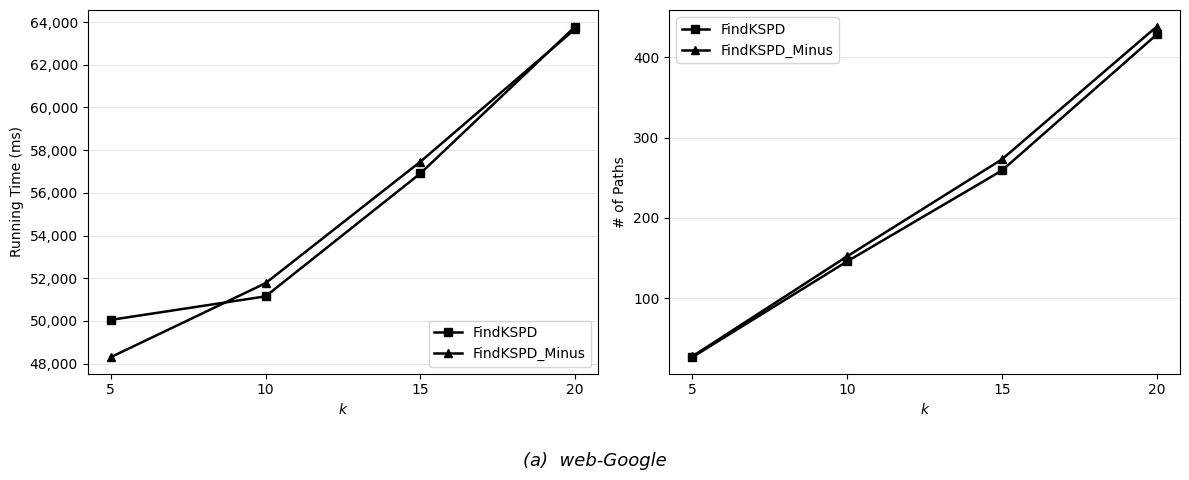

In [16]:
graph_types = ("web-Google",)

algorithms_paths = {
    'FindKSPD':       [r[0][1] for r in all_results],  # index 1 = avg_num_paths
    'FindKSPD_Minus': [r[1][1] for r in all_results],
}

algorithms_time = {
    'FindKSPD':       [r[0][0] for r in all_results],  # index 0 = avg_time
    'FindKSPD_Minus': [r[1][0] for r in all_results],
}

markers = {
    'FindKSPD':       's',  # □ kare
    'FindKSPD_Minus': '^',  # △ üçgen
}

draw_line_chart(k_list, markers, algorithms_paths, algorithms_time, graph_name="web-Google")

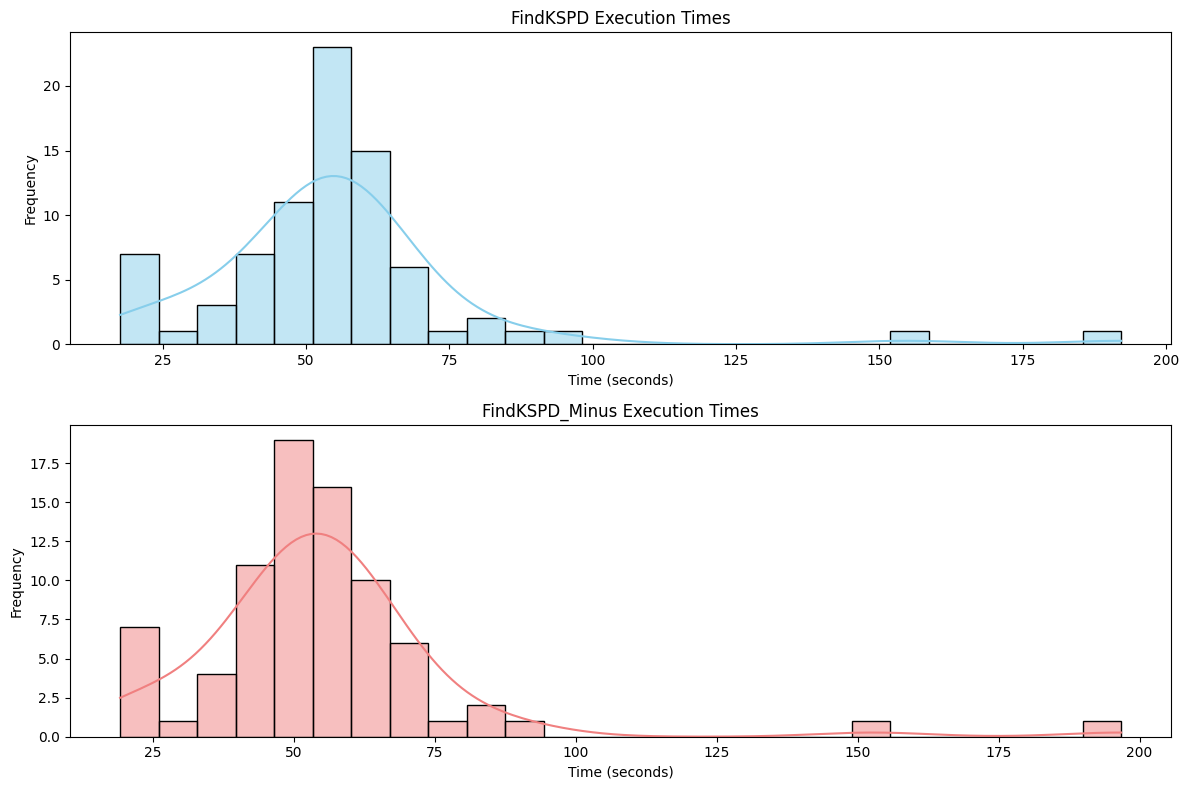

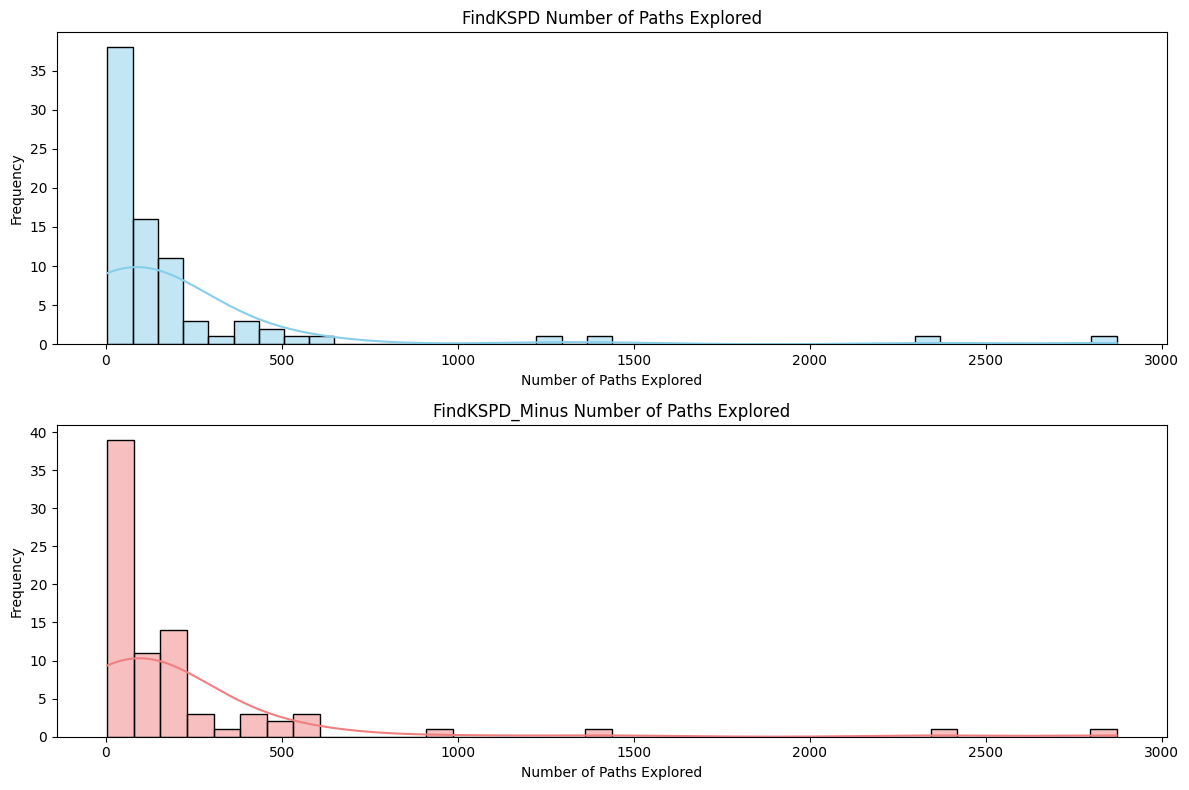

In [17]:
all_kspd_times = []
all_kspd_minus_times = []
all_kspd_num_paths = []
all_kspd_minus_num_paths = []

for result in all_results:
    all_kspd_times.extend(result[0][2])
    all_kspd_num_paths.extend(result[0][3])
    all_kspd_minus_times.extend(result[1][2])
    all_kspd_minus_num_paths.extend(result[1][3])

# Plotting distributions for times
plot_configs_time = [
    ('FindKSPD Execution Times', all_kspd_times, 'skyblue'),
    ('FindKSPD_Minus Execution Times', all_kspd_minus_times, 'lightcoral'),
]
draw_time_distribution(plot_configs_time)

# Plotting distributions for number of paths
plot_configs_num_paths = [
    ('FindKSPD Number of Paths Explored', all_kspd_num_paths, 'skyblue'),
    ('FindKSPD_Minus Number of Paths Explored', all_kspd_minus_num_paths, 'lightcoral'),
]
draw_num_of_path_distribution(plot_configs_num_paths)